# TRABAJO MATRIZ DE CONFUSIÓN

1) id: identificador único
2) gender: "Hombre", "Mujer" u "Otro"
3) age: edad del paciente
4) hypertension: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca
6) ever_casado: "No" o "Sí"
7) work_type: "niños", "Govt_jov", "Never_worked", "Privado" o "Autónomo"
8) Residence_type: "Rural" o "Urban"
9) avg_glucose_nivel: nivel promedio de glucosa en sangre
10) bmi: índice de masa corporal
11) smoking_status: "anteriormente fumado", "nunca fumado", "humo" o "Desconocido"*
12) stroke: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no
*Nota: "Desconocido" en smoking_status significa que la información no está disponible para este paciente

### LIBRERIAS 

In [541]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

## 1. Carga de datos

In [542]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

## 2. Exploración inicial

In [543]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [544]:
df = df.drop(columns=["id"])

In [545]:
df.shape

(5110, 11)

In [546]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [547]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
Name: stroke, dtype: float64

In [548]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 3. Limpieza de los datos

In [549]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [550]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [551]:
df.dropna(inplace=True)

In [552]:
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [553]:
df.shape

(4909, 11)

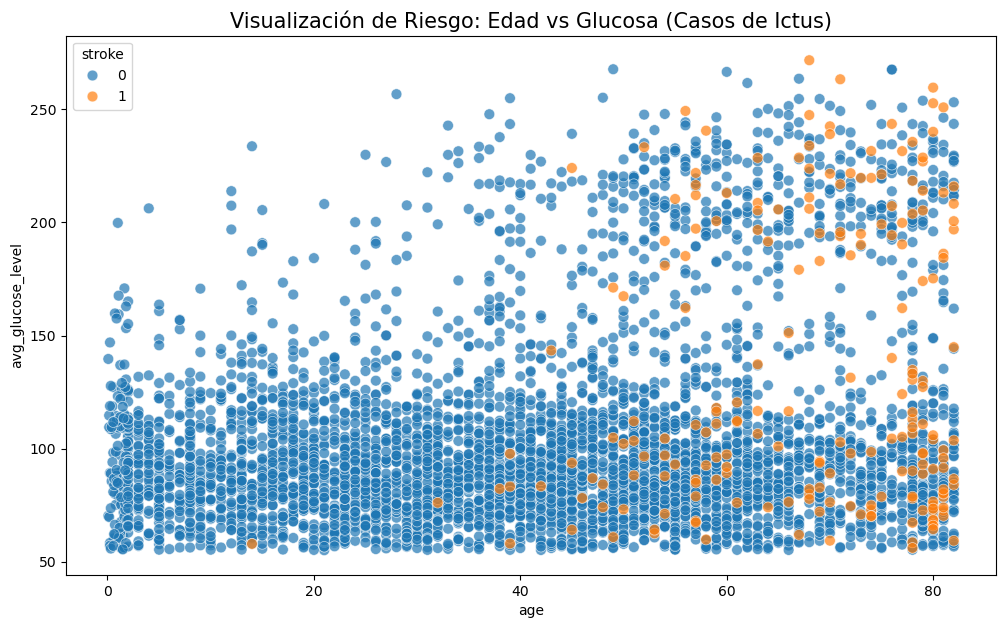

In [554]:
import seaborn as sns
import matplotlib.pyplot as plt

#Ordenamos para que los casos de stroke=1 se dibujen al final (encima de los demás)
df_plot = df.sort_values(by='stroke')

plt.figure(figsize=(12, 7))

#Usamos 's' para aumentar el tamaño de los puntos y 'edgecolor' para que no se mezclen
sns.scatterplot(data=df_plot, x='age', y='avg_glucose_level', 
                hue='stroke', palette=['#1f77b4', '#ff7f0e'], 
                alpha=0.7, s=60, edgecolor='w', linewidth=0.5)

plt.title('Visualización de Riesgo: Edad vs Glucosa (Casos de Ictus)', fontsize=15)
plt.show()

## 4. Selección de variables

In [555]:
df = pd.get_dummies(df,dtype=int)

In [556]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                               0.232331
hypertension                      0.142515
avg_glucose_level                 0.138936
heart_disease                     0.137938
ever_married_Yes                  0.105089
ever_married_No                   0.105089
work_type_children                0.080971
smoking_status_Unknown            0.075016
smoking_status_formerly smoked    0.057320
work_type_Self-employed           0.055356
bmi                               0.042374
smoking_status_smokes             0.021530
work_type_Private                 0.014934
work_type_Never_worked            0.014149
smoking_status_never smoked       0.010723
gender_Male                       0.006939
gender_Female                     0.006851
Residence_type_Rural              0.006031
Residence_type_Urban              0.006031
work_type_Govt_job                0.003553
gender_Other                      0.003010
Name: stroke, dtype: float64

In [557]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
5,81.0,0,0,186.21,29.0,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0


In [558]:
df.shape

(4909, 22)

In [559]:
df['stroke'].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

## 5. Definicion de X e y

In [560]:
X = df.drop(["stroke"],axis=1)
y = df["stroke"]

In [561]:
print(X.shape)
print(y.shape)

(4909, 21)
(4909,)


## 6. Escalado

In [562]:
# Guardamos el nombre de las variables para usarlo en el random forest
feature_names = df.drop("stroke", axis=1).columns

In [563]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [564]:
print("Primeros registros de X escalada:")
print(X[:5, :3])

Primeros registros de X escalada:
[[ 1.07013796 -0.31806673  4.38196829]
 [ 1.64656262 -0.31806673  4.38196829]
 [ 0.27201152 -0.31806673 -0.22820795]
 [ 1.60222226  3.14399438 -0.22820795]
 [ 1.69090297 -0.31806673 -0.22820795]]


## 7. Train/Test split

In [565]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (3927, 21)
X_test:  (982, 21)
y_train: (3927,)
y_test:  (982,)


## 8. Entrenamiento de modelos de clasificación

In [566]:

svm_model_balanced = SVC(kernel='poly', C=10, degree=3, coef0=0, probability=True, class_weight='balanced')
svm_model_balanced.fit(X_train, y_train)

y_pred_svm = svm_model_balanced.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8197556008146639
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90       940
           1       0.10      0.38      0.15        42

    accuracy                           0.82       982
   macro avg       0.53      0.61      0.53       982
weighted avg       0.93      0.82      0.87       982

SVM Confusion Matrix:
 [[789 151]
 [ 26  16]]


### LogisticRegression sin "class_weight='balanced'"

In [567]:
model_lr = LogisticRegression(max_iter=1000) 
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [568]:
y_pred_lr = model_lr.predict(X_test)
print(accuracy_score(y_test, y_pred_lr))

0.9572301425661914


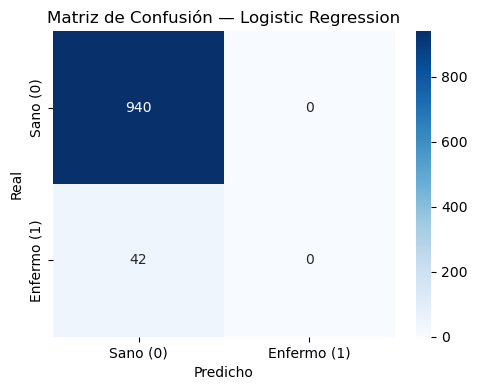

0.9572301425661914


In [569]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_lr))

### LogisticRegression con "class_weight='balanced'"

In [570]:
model_lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced') 
model_lr_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [571]:
y_pred_lr_balanced = model_lr_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_lr_balanced))

0.7566191446028513


In [572]:
# Stratified K-Fold divide los datos en partes, cada una con proporciones similares de cada clase
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_skf = X
y_skf = y

for train_index, test_index in skf.split(X_skf, y_skf):
    X_train_skf, X_test_skf = X_skf[train_index], X_skf[test_index]
    y_train_skf, y_test_skf = y_skf.iloc[train_index], y_skf.iloc[test_index]

    model_lr_balanced.fit(X_train_skf, y_train_skf)
    y_pred_skf = model_lr_balanced.predict(X_test_skf)

    acc = accuracy_score(y_test_skf, y_pred_skf)
    scores.append(acc)

print("Accuracy por fold:", scores)
print("Accuracy media:", np.mean(scores))

Accuracy por fold: [0.745417515274949, 0.7688391038696538, 0.7372708757637475, 0.7087576374745418, 0.7553516819571865]
Accuracy media: 0.7431273628680157


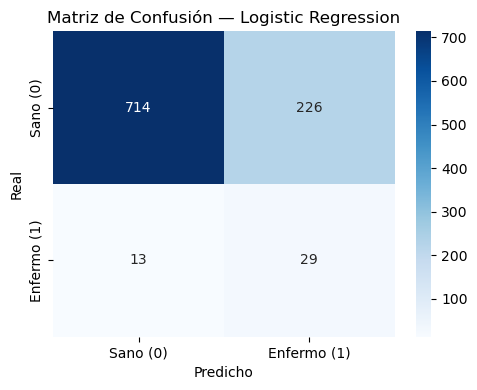

0.7566191446028513


In [573]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr_balanced)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_lr_balanced))

### RandomForestClassifier sin "class_weight='balanced'"

In [574]:
rf_clf = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)

In [575]:
y_pred_rf = rf_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))

0.9541751527494908


In [576]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

for feature, importance in importances.items():
    print(f"{feature}: {importance:.4f}")

avg_glucose_level: 0.2630
age: 0.2321
bmi: 0.2259
hypertension: 0.0335
heart_disease: 0.0251
smoking_status_never smoked: 0.0207
Residence_type_Urban: 0.0206
work_type_Private: 0.0198
gender_Male: 0.0194
Residence_type_Rural: 0.0192
gender_Female: 0.0190
work_type_Self-employed: 0.0180
smoking_status_formerly smoked: 0.0178
smoking_status_smokes: 0.0171
smoking_status_Unknown: 0.0139
work_type_Govt_job: 0.0134
ever_married_Yes: 0.0104
ever_married_No: 0.0102
work_type_children: 0.0010
work_type_Never_worked: 0.0000
gender_Other: 0.0000


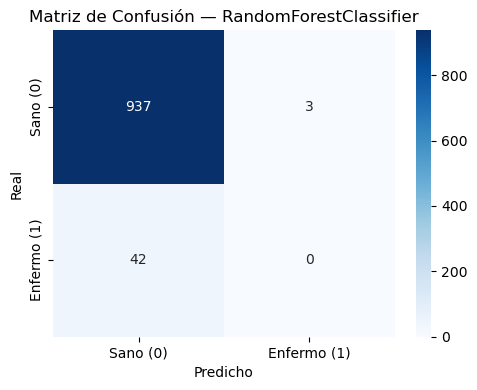

0.9541751527494908


In [577]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — RandomForestClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_rf))

### RandomForestClassifier con "class_weight='balanced'"

In [578]:
rf_clf_balanced = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42, class_weight="balanced")
rf_clf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=600, n_jobs=1,
                       random_state=42)

In [579]:
y_pred_rf_balanced = rf_clf_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_rf_balanced))

0.9562118126272913


In [580]:
# Stratified K-Fold divide los datos en partes, cada una con proporciones similares de cada clase
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_skf = X
y_skf = y

for train_index, test_index in skf.split(X_skf, y_skf):
    X_train_skf, X_test_skf = X_skf[train_index], X_skf[test_index]
    y_train_skf, y_test_skf = y_skf.iloc[train_index], y_skf.iloc[test_index]

    rf_clf_balanced.fit(X_train_skf, y_train_skf)
    y_pred_skf = rf_clf_balanced.predict(X_test_skf)

    acc = accuracy_score(y_test_skf, y_pred_skf)
    scores.append(acc)

print("Accuracy por fold:", scores)
print("Accuracy media:", np.mean(scores))

Accuracy por fold: [0.9572301425661914, 0.9582484725050916, 0.9531568228105907, 0.9562118126272913, 0.9571865443425076]
Accuracy media: 0.9564067589703346


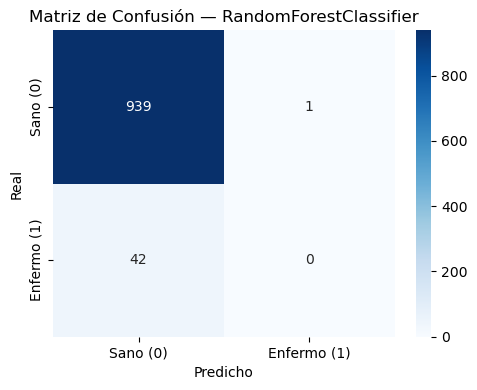

0.9562118126272913


In [581]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf_balanced)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — RandomForestClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_rf_balanced))

### ACCURACY / F1-SCORE / PRECISION / RECALL / ROC-AUC

In [582]:
print("Logistic Regression Balanced Classification Report:\n", classification_report(y_test, y_pred_lr_balanced))

Logistic Regression Balanced Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.76      0.86       940
           1       0.11      0.69      0.20        42

    accuracy                           0.76       982
   macro avg       0.55      0.73      0.53       982
weighted avg       0.94      0.76      0.83       982



A la hora de observar las distintas metricas, si usamos "classification_report", no dará dichas metricas por cada clase por separado, pero al analizar cada metrica por separado podemos ver en la siguiente celda que obtenemos cada porcentaje de cada metrica basandose en ambas clases, no en cada uno en especifico como hace el "classification_report".

In [583]:
models = {
    "Logistic Regression": model_lr,
    "Logistic Regression Balanced": model_lr_balanced,
    "Random Forest": rf_clf,
    "Random Forest Balanced": rf_clf_balanced,
    "SVM Poly Balanced": svm_model_balanced
}

# Usar una lista de diccionarios es más limpio para luego crear un DataFrame
results_list = []

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Manejo de probabilidades para ROC-AUC (Evita errores con SVM)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # En caso de que el modelo no soporte probabilidades (como un SVC sin probability=True)
        # se usan los decision_function o se avisa del error
        y_prob = model.decision_function(X_test) 

    # Cálculo de métricas
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    
    results_list.append(metrics)

    print(f"\n--- {name} ---")
    for metric, value in metrics.items():
        if metric != "Model":
            print(f"{metric:10}: {value:.4f}")


--- Logistic Regression ---
Accuracy  : 0.9572
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.8136

--- Logistic Regression Balanced ---
Accuracy  : 0.7566
Precision : 0.1137
Recall    : 0.6905
F1-score  : 0.1953
ROC-AUC   : 0.8104


/home/ciabd14/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Random Forest ---
Accuracy  : 0.9542
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.7423

--- Random Forest Balanced ---
Accuracy  : 0.9562
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.7576

--- SVM Poly Balanced ---
Accuracy  : 0.8198
Precision : 0.0958
Recall    : 0.3810
F1-score  : 0.1531
ROC-AUC   : 0.6652
